In [3]:
# ═══════════════════════════════════════════════════════════════════
# CELL 1 — System Check & Environment Setup
# ═══════════════════════════════════════════════════════════════════

import torch, platform, psutil, sys, os

print("=" * 70)
print("  SYSTEM CHECK")
print("=" * 70)

# Detect environment
IN_COLAB = 'google.colab' in sys.modules
print(f"Environment : {'Google Colab' if IN_COLAB else 'Local / VS Code'}")
print(f"OS          : {platform.system()} {platform.release()}")

# GPU
if torch.cuda.is_available():
    gpu = torch.cuda.get_device_name(0)
    vram = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print(f"GPU         : {gpu}  ({vram:.1f} GB VRAM)")
    print(f"CUDA        : {torch.version.cuda}")
    BATCH_SIZE = 128    # Deepika et al. (2023): batch_size=128 is optimal for GTSRB
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    print("GPU         : Apple Silicon (MPS)")
    BATCH_SIZE = 128
else:
    print("GPU         : None — CPU only (training will be slow)")
    BATCH_SIZE = 64     # CPU: use smaller batch to avoid OOM

ram = psutil.virtual_memory().total / 1024**3
print(f"RAM         : {ram:.1f} GB")
print(f"Python      : {platform.python_version()}")
print(f"PyTorch     : {torch.__version__}")

device = torch.device('cuda' if torch.cuda.is_available()
                      else 'mps' if hasattr(torch.backends, 'mps') and torch.backends.mps.is_available()
                      else 'cpu')
print(f"\nDEVICE      : {device}")
print(f"BATCH SIZE  : {BATCH_SIZE}")
print("=" * 70)

  SYSTEM CHECK
Environment : Google Colab
OS          : Linux 6.6.105+
GPU         : Tesla T4  (14.7 GB VRAM)
CUDA        : 12.6
RAM         : 12.7 GB
Python      : 3.12.12
PyTorch     : 2.9.0+cu126

DEVICE      : cuda
BATCH SIZE  : 128


In [4]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 1B — ENVIRONMENT & SAVE PATH CONFIGURATION (Colab vs Local)
# ═══════════════════════════════════════════════════════════════════════════
# - Colab: mounts Drive, saves models/checkpoints/results/plots to Drive
# - Local: saves everything to current working directory
# - Colab checkpoints every 2 epochs + on every best accuracy improvement
# ═══════════════════════════════════════════════════════════════════════════

import sys, os
from pathlib import Path

# ── Detect environment ──
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')

    SAVE_DIR       = Path('/content/drive/MyDrive/GTSRB_Project')
    CHECKPOINT_DIR = SAVE_DIR / 'checkpoints'
    RESULTS_DIR    = SAVE_DIR / 'results'
    PLOTS_DIR      = SAVE_DIR / 'plots'
    DATA_CACHE_DIR = SAVE_DIR / 'data_cache'   # cache dataset on Drive

    for d in [SAVE_DIR, CHECKPOINT_DIR, RESULTS_DIR, PLOTS_DIR, DATA_CACHE_DIR]:
        d.mkdir(parents=True, exist_ok=True)

    print("╔══════════════════════════════════════════════════════════╗")
    print("║  GOOGLE COLAB DETECTED — Google Drive Mounted           ║")
    print("╠══════════════════════════════════════════════════════════╣")
    print(f"║  Models         : {str(SAVE_DIR):<38} ║")
    print(f"║  Checkpoints    : {str(CHECKPOINT_DIR):<38} ║")
    print(f"║  Data Cache     : {str(DATA_CACHE_DIR):<38} ║")
    print(f"║  Results (CSV)  : {str(RESULTS_DIR):<38} ║")
    print(f"║  Plots (PNG)    : {str(PLOTS_DIR):<38} ║")
    print("╚══════════════════════════════════════════════════════════╝")
else:
    SAVE_DIR       = Path('.')
    CHECKPOINT_DIR = None
    RESULTS_DIR    = Path('.')
    PLOTS_DIR      = Path('.')
    DATA_CACHE_DIR = None

    print("╔══════════════════════════════════════════════════════════╗")
    print("║  LOCAL ENVIRONMENT — Files saved to working directory   ║")
    print("╠══════════════════════════════════════════════════════════╣")
    print(f"║  Save Dir       : {str(SAVE_DIR.resolve()):<38} ║")
    print(f"║  Checkpoints    : N/A (local — not needed)             ║")
    print("╚══════════════════════════════════════════════════════════╝")

# ═══════════════════════════════════════════════════════════════════════════
# HELPER FUNCTIONS — used throughout the notebook
# ═══════════════════════════════════════════════════════════════════════════

def get_model_save_path(model_name):
    """Full path to save a trained model .pth file."""
    return SAVE_DIR / f'ieee_model_{model_name}.pth'

def get_checkpoint_path(model_name, epoch):
    """Full path for an intermediate checkpoint (Colab Drive only)."""
    if CHECKPOINT_DIR:
        return CHECKPOINT_DIR / f'ckpt_{model_name}_epoch{epoch}.pth'
    return None

def verify_save(filepath):
    """Verify a file was actually written to disk/Drive successfully."""
    p = Path(filepath)
    if p.exists():
        size_mb = p.stat().st_size / (1024 * 1024)
        if size_mb > 0.001:  # > 1 KB
            return True, size_mb
    return False, 0.0

def save_checkpoint(model, optimizer, scheduler, epoch, best_acc, history, model_name, cfg):
    """Save intermediate training checkpoint to Drive (Colab only).
    Called every 2 epochs + on every new best accuracy.
    Keeps only last 3 checkpoints to save Drive space."""
    if not IN_COLAB or CHECKPOINT_DIR is None:
        return
    ckpt_path = get_checkpoint_path(model_name, epoch)
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'best_acc': best_acc,
        'history': history,
        'config': cfg,
    }, ckpt_path)
    ok, size = verify_save(ckpt_path)
    if ok:
        print(f"    💾 Checkpoint → Drive ({ckpt_path.name}, {size:.1f} MB)")
    else:
        print(f"    ⚠ Checkpoint FAILED to save: {ckpt_path}")
    # Keep only last 3 checkpoints
    existing = sorted(CHECKPOINT_DIR.glob(f'ckpt_{model_name}_epoch*.pth'))
    while len(existing) > 3:
        existing[0].unlink()
        existing.pop(0)

def load_checkpoint(model_name):
    """Load the latest checkpoint for a model if available (Colab only)."""
    if not IN_COLAB or CHECKPOINT_DIR is None:
        return None
    existing = sorted(CHECKPOINT_DIR.glob(f'ckpt_{model_name}_epoch*.pth'))
    if existing:
        latest = existing[-1]
        print(f"  ↻ Found Drive checkpoint: {latest.name}")
        return torch.load(latest, map_location=device)
    return None

def save_model_verified(save_data, filepath, label=""):
    """Save a .pth file and verify it was written successfully."""
    torch.save(save_data, filepath)
    ok, size = verify_save(filepath)
    if ok:
        print(f"  ✔ Saved {label}: {Path(filepath).name} ({size:.1f} MB)")
    else:
        print(f"  ✗ SAVE FAILED {label}: {filepath}")
    return ok

def save_plot(fig, filename):
    """Save a figure to the correct directory."""
    fig.savefig(PLOTS_DIR / filename, dpi=150, bbox_inches='tight')

def save_csv(df, filename):
    """Save a DataFrame to the correct directory."""
    df.to_csv(RESULTS_DIR / filename, index=False)

print("\n✅ Environment configured — all save/verify helpers ready.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
╔══════════════════════════════════════════════════════════╗
║  GOOGLE COLAB DETECTED — Google Drive Mounted           ║
╠══════════════════════════════════════════════════════════╣
║  Models         : /content/drive/MyDrive/GTSRB_Project   ║
║  Checkpoints    : /content/drive/MyDrive/GTSRB_Project/checkpoints ║
║  Data Cache     : /content/drive/MyDrive/GTSRB_Project/data_cache ║
║  Results (CSV)  : /content/drive/MyDrive/GTSRB_Project/results ║
║  Plots (PNG)    : /content/drive/MyDrive/GTSRB_Project/plots ║
╚══════════════════════════════════════════════════════════╝

✅ Environment configured — all save/verify helpers ready.


# GTSRB Traffic Sign Recognition — Full Pipeline

**Models**: ConvNeXt-Tiny · ResNet18 · EfficientNet-B0 → Ensemble  
**Dataset**: Full GTSRB (43 classes, 0–42) with class balancing  
**Output**: Accuracy / Precision / Recall / F1 / ROC-AUC tables, saved `.pth` models

In [10]:
# ═══════════════════════════════════════════════════════════════════
# CELL 2 — Download FULL GTSRB Dataset (all 43 classes, 0–42)
#   Colab: caches data to Drive so reconnects skip re-download
#   Local: downloads normally to model_data/
# ═══════════════════════════════════════════════════════════════════

import kagglehub, pandas as pd, shutil
from pathlib import Path

LOCAL_DATA = Path("model_data")

# ── Check if data already exists (Drive cache or local) ──
def data_ready(data_dir):
    """Check if model_data has train/test with ≥ 43 class folders."""
    t = data_dir / "train"
    te = data_dir / "test"
    if t.exists() and te.exists():
        n_train = len([d for d in t.iterdir() if d.is_dir()])
        n_test  = len([d for d in te.iterdir() if d.is_dir()])
        return n_train >= 43 and n_test >= 43
    return False

# ── Try to restore from Drive cache first (Colab only) ──
if IN_COLAB and DATA_CACHE_DIR and data_ready(DATA_CACHE_DIR):
    print("Found dataset cached on Google Drive — restoring (no download needed)...")
    if LOCAL_DATA.exists():
        shutil.rmtree(LOCAL_DATA)
    shutil.copytree(DATA_CACHE_DIR, LOCAL_DATA)
    print(f"  ✔ Restored from Drive: {DATA_CACHE_DIR}")
    print(f"  Train classes: {len(list((LOCAL_DATA/'train').iterdir()))}")
    print(f"  Test classes:  {len(list((LOCAL_DATA/'test').iterdir()))}")

elif data_ready(LOCAL_DATA):
    print(f"Dataset already present at {LOCAL_DATA.resolve()} — skipping download.")
    print(f"  Train classes: {len(list((LOCAL_DATA/'train').iterdir()))}")
    print(f"  Test classes:  {len(list((LOCAL_DATA/'test').iterdir()))}")

else:
    # ── Download from Kaggle ──
    print("Downloading GTSRB from Kaggle...")
    dataset_path = kagglehub.dataset_download("meowmeowmeowmeowmeow/gtsrb-german-traffic-sign")
    root = Path(dataset_path)
    print(f"  Downloaded to: {root}")

    train_csv = root / 'Train.csv'
    test_csv  = root / 'Test.csv'

    def copy_all_classes(csv_path, split_name):
        """Copy ALL classes from GTSRB — no filtering."""
        df = pd.read_csv(csv_path)
        out_dir = LOCAL_DATA / split_name
        count = 0
        n_classes = df['ClassId'].nunique()
        for _, row in df.iterrows():
            cls_id = row['ClassId']
            img_path = root / row['Path']
            if img_path.exists():
                dest_dir = out_dir / str(cls_id)
                dest_dir.mkdir(parents=True, exist_ok=True)
                dest_file = dest_dir / img_path.name
                if not dest_file.exists():
                    shutil.copy2(img_path, dest_file)
                    count += 1
        print(f"    {split_name}: {count} images ({n_classes} classes)")

    copy_all_classes(train_csv, 'train')
    copy_all_classes(test_csv,  'test')

    # ── Cache to Drive so next Colab session skips download ──
    if IN_COLAB and DATA_CACHE_DIR:
        print("\n  Caching dataset to Google Drive (one-time)...")
        if DATA_CACHE_DIR.exists():
            shutil.rmtree(DATA_CACHE_DIR)
        shutil.copytree(LOCAL_DATA, DATA_CACHE_DIR)
        ok = data_ready(DATA_CACHE_DIR)
        print(f"  {'✔ Cached to Drive!' if ok else '⚠ Cache failed'}: {DATA_CACHE_DIR}")

# ── Final verification ──
train_classes = len([d for d in (LOCAL_DATA / "train").iterdir() if d.is_dir()])
test_classes  = len([d for d in (LOCAL_DATA / "test").iterdir() if d.is_dir()])
total_train   = sum(len(list(d.iterdir())) for d in (LOCAL_DATA / "train").iterdir() if d.is_dir())
total_test    = sum(len(list(d.iterdir())) for d in (LOCAL_DATA / "test").iterdir() if d.is_dir())

print(f"\n{'='*60}")
print(f"  GTSRB Dataset Ready")
print(f"  Classes: {train_classes} train / {test_classes} test")
print(f"  Images:  {total_train:,} train / {total_test:,} test")
print(f"  Location: {LOCAL_DATA.resolve()}")
if IN_COLAB and DATA_CACHE_DIR:
    print(f"  Drive cache: {DATA_CACHE_DIR}")
print(f"{'='*60}")

Dataset already present at /content/model_data — skipping download.
  Train classes: 43
  Test classes:  43

  GTSRB Dataset Ready
  Classes: 43 train / 43 test
  Images:  39,209 train / 12,630 test
  Location: /content/model_data
  Drive cache: /content/drive/MyDrive/GTSRB_Project/data_cache


## Preprocessing & Class Balance Analysis

Dataset at: /content/model_data
Class  Sign Name                          Train   Test       %
--------------------------------------------------------------------------------
    0  Speed limit (20km/h)                 210     60    0.5%
    1  Speed limit (30km/h)               2,220    720    5.7%
    2  Speed limit (50km/h)               2,250    750    5.7%
    3  Speed limit (60km/h)               1,410    450    3.6%
    4  Speed limit (70km/h)               1,980    660    5.0%
    5  Speed limit (80km/h)               1,860    630    4.7%
    6  End of 80km/h limit                  420    150    1.1%
    7  Speed limit (100km/h)              1,440    450    3.7%
    8  Speed limit (120km/h)              1,410    450    3.6%
    9  No passing                         1,470    480    3.7%
   10  No passing (>3.5t)                 2,010    660    5.1%
   11  Right-of-way at intersection       1,320    420    3.4%
   12  Priority road                      2,100    690    5.4%
   13

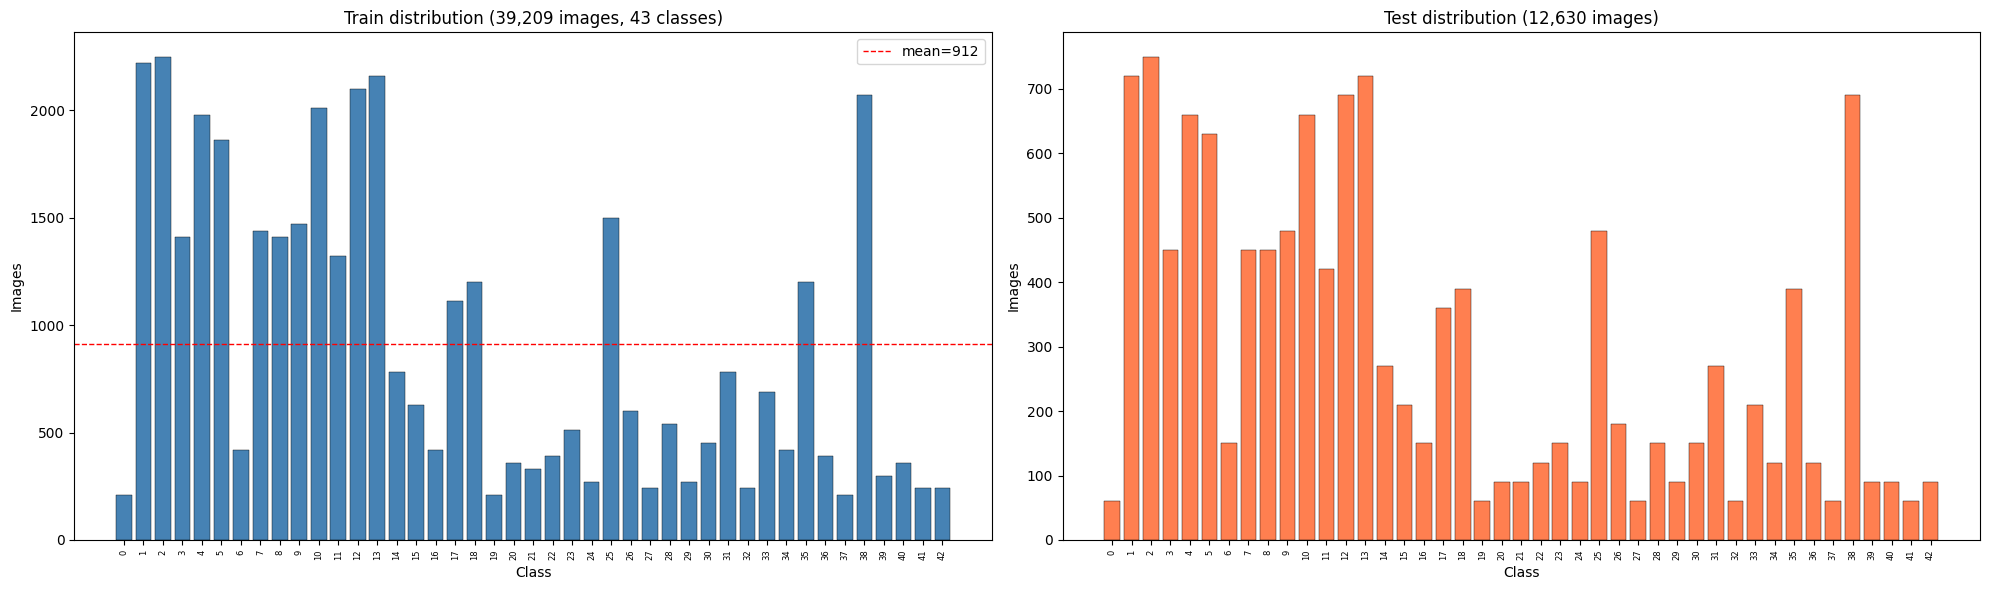

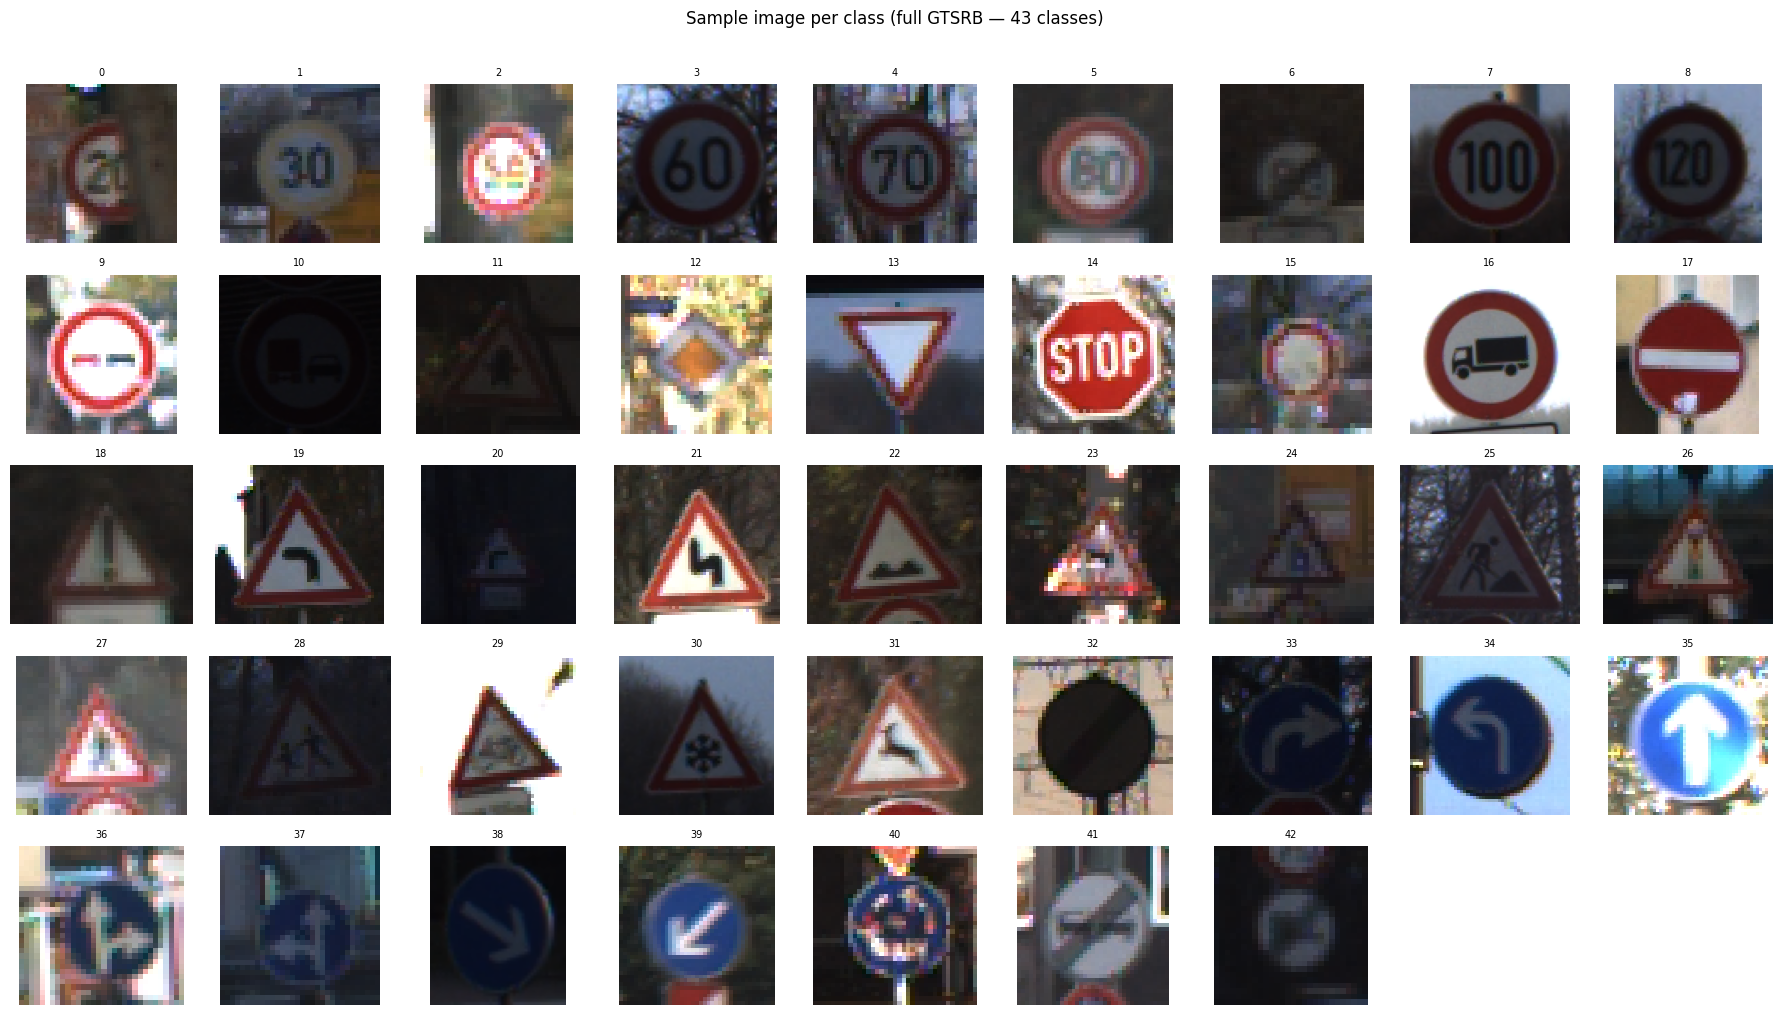


✅ Preprocessing complete — 43 classes, 39,209 train, 12,630 test.


In [11]:
# ═══════════════════════════════════════════════════════════════════
# CELL 3 — Preprocessing: class distribution, balance check, plots
#          Full GTSRB — all 43 classes (0–42)
# ═══════════════════════════════════════════════════════════════════

import numpy as np, matplotlib.pyplot as plt, matplotlib.image as mpimg
from pathlib import Path
from PIL import Image
import random, math

# --- locate model_data (works on Colab & local) ---
_candidates = [Path("model_data"), Path("/content/model_data"),
               Path.home() / "Desktop" / "llm" / "model_data"]
DATA_DIR = next((p for p in _candidates
                 if (p / "train").exists() and (p / "test").exists()), None)
if DATA_DIR is None:
    raise FileNotFoundError("model_data/train not found — run the download cell first")

TRAIN_DIR = DATA_DIR / "train"
TEST_DIR  = DATA_DIR / "test"
print(f"Dataset at: {DATA_DIR.resolve()}")

# ── Full GTSRB sign names — all 43 classes ──
SIGN_NAMES = {
    0:  "Speed limit (20km/h)",
    1:  "Speed limit (30km/h)",
    2:  "Speed limit (50km/h)",
    3:  "Speed limit (60km/h)",
    4:  "Speed limit (70km/h)",
    5:  "Speed limit (80km/h)",
    6:  "End of 80km/h limit",
    7:  "Speed limit (100km/h)",
    8:  "Speed limit (120km/h)",
    9:  "No passing",
    10: "No passing (>3.5t)",
    11: "Right-of-way at intersection",
    12: "Priority road",
    13: "Yield",
    14: "Stop",
    15: "No vehicles",
    16: "Vehicles >3.5t prohibited",
    17: "No entry",
    18: "General caution",
    19: "Dangerous curve left",
    20: "Dangerous curve right",
    21: "Double curve",
    22: "Bumpy road",
    23: "Slippery road",
    24: "Road narrows on right",
    25: "Road work",
    26: "Traffic signals",
    27: "Pedestrians",
    28: "Children crossing",
    29: "Bicycles crossing",
    30: "Beware of ice/snow",
    31: "Wild animals crossing",
    32: "End speed + passing limits",
    33: "Turn right ahead",
    34: "Turn left ahead",
    35: "Ahead only",
    36: "Go straight or right",
    37: "Go straight or left",
    38: "Keep right",
    39: "Keep left",
    40: "Roundabout mandatory",
    41: "End of no passing",
    42: "End no passing (>3.5t)",
}

def count_per_class(root):
    counts = {}
    for d in sorted(root.iterdir()):
        if d.is_dir():
            counts[int(d.name)] = len([f for f in d.iterdir() if f.is_file()])
    return dict(sorted(counts.items()))

train_counts = count_per_class(TRAIN_DIR)
test_counts  = count_per_class(TEST_DIR)
total_train  = sum(train_counts.values())
total_test   = sum(test_counts.values())

# --- summary table ---
print("=" * 80)
print(f"{'Class':>5}  {'Sign Name':<32} {'Train':>7} {'Test':>6}  {'%':>6}")
print("-" * 80)
for c in train_counts:
    print(f"{c:>5}  {SIGN_NAMES.get(c,'?'):<32} {train_counts[c]:>7,} "
          f"{test_counts.get(c,0):>6,}  {100*train_counts[c]/total_train:>5.1f}%")
print("-" * 80)
print(f"{'TOTAL':>5}  {'':32} {total_train:>7,} {total_test:>6,}")
print(f"\nTotal classes: {len(train_counts)}")
print("=" * 80)

# --- balance analysis ---
arr = np.array(list(train_counts.values()))
ratio = arr.max() / arr.min()
print(f"\nImbalance ratio (max/min): {ratio:.2f}x  (max={arr.max()}, min={arr.min()})")
if ratio > 3:
    print("⚠️  IMBALANCED — WeightedRandomSampler will be used for training.")
elif ratio > 1.5:
    print("⚡ Moderately imbalanced.")
else:
    print("✅ Reasonably balanced.")

# --- bar chart ---
classes = list(train_counts.keys())
x = np.arange(len(classes))
fig, axes = plt.subplots(1, 2, figsize=(20, 6))
bars = axes[0].bar(x, [train_counts[c] for c in classes], color='steelblue', edgecolor='k', linewidth=0.3)
axes[0].axhline(arr.mean(), color='red', ls='--', lw=1, label=f'mean={arr.mean():.0f}')
axes[0].set_xticks(x); axes[0].set_xticklabels(classes, rotation=90, fontsize=6)
axes[0].set_xlabel("Class"); axes[0].set_ylabel("Images")
axes[0].set_title(f"Train distribution ({total_train:,} images, {len(classes)} classes)")
axes[0].legend()

bars2 = axes[1].bar(x, [test_counts.get(c,0) for c in classes], color='coral', edgecolor='k', linewidth=0.3)
axes[1].set_xticks(x); axes[1].set_xticklabels(classes, rotation=90, fontsize=6)
axes[1].set_xlabel("Class"); axes[1].set_ylabel("Images")
axes[1].set_title(f"Test distribution ({total_test:,} images)")
plt.tight_layout(); plt.show()

# --- sample images (adaptive grid for 43 classes) ---
n_cols = 9
n_rows = math.ceil(len(classes) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 2*n_rows))
axes_flat = axes.flatten()
for i, c in enumerate(classes):
    imgs = list((TRAIN_DIR / str(c)).glob("*"))
    if imgs:
        axes_flat[i].imshow(mpimg.imread(str(random.choice(imgs))))
    axes_flat[i].set_title(f"{c}", fontsize=7); axes_flat[i].axis('off')
for j in range(len(classes), len(axes_flat)):
    axes_flat[j].axis('off')
fig.suptitle("Sample image per class (full GTSRB — 43 classes)", y=1.01, fontsize=12)
plt.tight_layout(); plt.show()

print(f"\n✅ Preprocessing complete — {len(classes)} classes, {total_train:,} train, {total_test:,} test.")

## Imports, Data Loaders & Class Balancing

In [12]:
# ═══════════════════════════════════════════════════════════════════
# CELL 4 — Imports + Data Loaders with STRONG Augmentation
#          (Deepika et al., 2023 — 99.81% GTSRB strategy)
# ═══════════════════════════════════════════════════════════════════
# Augmentation rationale — Deepika et al. (2023) key insights:
#   ✓ Rotation ±20° — more aggressive (real-world sign tilt)
#   ✓ GaussianBlur — simulates camera defocus / motion blur
#   ✓ Gaussian noise injection — sensor noise robustness
#   ✓ Strong illumination jitter — day/night/shadow conditions
#   ✓ Adam optimizer, batch_size=128 (set in Cell 1)
#   ✗ NO RandomGrayscale — red/blue/yellow colors are discriminative
# ═══════════════════════════════════════════════════════════════════

import torch, torch.nn as nn, torch.optim as optim, torch.nn.functional as F
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import transforms, datasets, models as tv_models
import numpy as np, pandas as pd, time, warnings, os
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             confusion_matrix, classification_report)
import seaborn as sns, matplotlib.pyplot as plt
from collections import Counter
from tqdm import tqdm
from datetime import datetime
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available()
                      else 'mps' if hasattr(torch.backends,'mps') and torch.backends.mps.is_available()
                      else 'cpu')
print(f"Device: {device}")

# --- paths (robust) ---
_candidates = [Path("model_data"), Path("/content/model_data"),
               Path.home()/"Desktop"/"llm"/"model_data"]
DATA_DIR = next((p for p in _candidates
                 if (p/"train").exists() and (p/"test").exists()), None)
train_dir = DATA_DIR / "train"
test_dir  = DATA_DIR / "test"

IMG_SIZE = 32

# ── Custom transform: Gaussian noise (Deepika et al.) ──
class AddGaussianNoise:
    """Adds Gaussian noise to tensor — simulates camera sensor noise.
    Deepika et al. (2023) found this critical for real-world robustness."""
    def __init__(self, mean=0.0, std=0.02):
        self.mean = mean
        self.std = std
    def __call__(self, tensor):
        noise = torch.randn_like(tensor) * self.std + self.mean
        return torch.clamp(tensor + noise, 0.0, 1.0)
    def __repr__(self):
        return f'{self.__class__.__name__}(mean={self.mean}, std={self.std})'

# ── STRONG augmentation (Deepika et al. 2023 strategy) ──
# Rotation ±20°, illumination jitter, Gaussian blur + noise
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE + 4, IMG_SIZE + 4)),          # slight upscale for crop margin
    transforms.RandomCrop(IMG_SIZE, padding=2, fill=128),     # small spatial jitter
    transforms.RandomRotation(20, fill=128),                  # ±20° (Deepika: real-world tilt)
    transforms.RandomAffine(0, translate=(0.1, 0.1),          # mild translation
                            scale=(0.85, 1.15), fill=128),    # wider scale range
    transforms.ColorJitter(brightness=0.3, contrast=0.3,      # STRONG illumination (Deepika)
                           saturation=0.25, hue=0.05),        # day/night/shadow simulation
    transforms.RandomAdjustSharpness(2.0, p=0.3),             # sharpness variation
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 0.5)), # camera defocus (Deepika)
    transforms.ToTensor(),
    AddGaussianNoise(mean=0.0, std=0.02),                     # sensor noise (Deepika)
    transforms.Normalize([0.3337, 0.3064, 0.3171],            # GTSRB-specific mean
                         [0.2672, 0.2564, 0.2629]),            # GTSRB-specific std
    transforms.RandomErasing(p=0.15, scale=(0.02, 0.15)),     # occlusion robustness
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.3337, 0.3064, 0.3171],
                         [0.2672, 0.2564, 0.2629]),
])

train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
test_dataset  = datasets.ImageFolder(test_dir,  transform=test_transform)

# --- weighted sampler for class balance ---
targets = [train_dataset[i][1] for i in range(len(train_dataset))]
class_counts = Counter(targets)
total = len(targets)
class_weights = {c: total/n for c, n in class_counts.items()}
sample_weights = torch.DoubleTensor([class_weights[t] for t in targets])
sampler = WeightedRandomSampler(sample_weights, len(sample_weights))

NUM_WORKERS = 4 if torch.cuda.is_available() else 2
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE*2, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

NUM_CLASSES = len(train_dataset.classes)

print(f"Train: {len(train_dataset):,}  |  Test: {len(test_dataset):,}  |  Classes: {NUM_CLASSES}")
print(f"Class-balanced sampling: ON  |  Batch: {BATCH_SIZE}")
print(f"Augmentation: STRONG (Deepika et al. 2023 — rotation ±20°, GaussianBlur, noise injection)")
print(f"  + ColorJitter(0.3, 0.3, 0.25) + GaussianNoise(std=0.02) + RandomErasing(p=0.15)")
print(f"Normalization: GTSRB-specific (mean=[.334,.306,.317], std=[.267,.256,.263])")
print("✅ Data pipeline ready (Deepika et al. 2023 augmentation strategy).")

Device: cuda
Train: 39,209  |  Test: 12,630  |  Classes: 43
Class-balanced sampling: ON  |  Batch: 128
Augmentation: STRONG (Deepika et al. 2023 — rotation ±20°, GaussianBlur, noise injection)
  + ColorJitter(0.3, 0.3, 0.25) + GaussianNoise(std=0.02) + RandomErasing(p=0.15)
Normalization: GTSRB-specific (mean=[.334,.306,.317], std=[.267,.256,.263])
✅ Data pipeline ready (Deepika et al. 2023 augmentation strategy).


In [13]:
# ═══════════════════════════════════════════════════════════════════
# CELL 5 — Model Architectures: ConvNeXt-Tiny, ResNet18, EfficientNet-B0
#          Full GTSRB — 43 classes
# ═══════════════════════════════════════════════════════════════════

# ---- 1. ConvNeXt-Tiny ----
# Best for: complex feature hierarchies, modern architecture
# Modification: stride=1 first conv for 32×32 input instead of stride=4
class ConvNeXtTinyTraffic(nn.Module):
    def __init__(self, num_classes=43, pretrained=True):
        super().__init__()
        self.backbone = tv_models.convnext_tiny(
            weights='IMAGENET1K_V1' if pretrained else None)
        # Replace stride-4 stem with stride-1 for 32×32 input
        self.backbone.features[0][0] = nn.Conv2d(3, 96, 3, stride=1, padding=1)
        in_feat = self.backbone.classifier[2].in_features
        self.backbone.classifier = nn.Sequential(
            nn.Flatten(1), nn.LayerNorm(in_feat),
            nn.Linear(in_feat, 512), nn.GELU(), nn.Dropout(0.3),
            nn.Linear(512, num_classes))
    def forward(self, x):
        return self.backbone(x)

# ---- 2. Enhanced ResNet18 ----
# Best for: fast training, solid baseline, proven on traffic signs
# Modification: stride-1 conv1, no maxpool (preserves spatial info at 32×32)
class EnhancedResNet18(nn.Module):
    def __init__(self, num_classes=43, pretrained=True):
        super().__init__()
        resnet = tv_models.resnet18(weights='IMAGENET1K_V1' if pretrained else None)
        resnet.conv1 = nn.Conv2d(3, 64, 3, stride=1, padding=1, bias=False)
        resnet.maxpool = nn.Identity()
        self.features = nn.Sequential(
            resnet.conv1, resnet.bn1, resnet.relu, resnet.maxpool,
            resnet.layer1, resnet.layer2, resnet.layer3, resnet.layer4)
        in_feat = resnet.fc.in_features
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(in_feat, 512), nn.ReLU(True), nn.Dropout(0.4),
            nn.Linear(512, 256), nn.ReLU(True), nn.Dropout(0.25),
            nn.Linear(256, num_classes))
        # Freeze only the very first layers — unfreeze more for 43-class task
        for i, layer in enumerate(self.features):
            if i <= 3:  # freeze conv1, bn1, relu, identity (NOT layer1)
                for p in layer.parameters(): p.requires_grad = False
    def forward(self, x):
        return self.classifier(self.features(x))

# ---- 3. EfficientNet-B0 ----
# Best for: parameter efficiency, compound scaling
# Modification: stride-1 stem conv for 32×32
class EfficientNetB0Traffic(nn.Module):
    def __init__(self, num_classes=43, pretrained=True):
        super().__init__()
        self.backbone = tv_models.efficientnet_b0(
            weights='IMAGENET1K_V1' if pretrained else None)
        self.backbone.features[0][0] = nn.Conv2d(3, 32, 3, stride=1, padding=1, bias=False)
        in_feat = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(in_feat, 512), nn.SiLU(True), nn.Dropout(0.2),
            nn.Linear(512, num_classes))
    def forward(self, x):
        return self.backbone(x)

# --- factory ---
MODEL_REGISTRY = {
    'convnext_tiny':   ConvNeXtTinyTraffic,
    'resnet18':        EnhancedResNet18,
    'efficientnet_b0': EfficientNetB0Traffic,
}

def get_model(name, num_classes=43):
    return MODEL_REGISTRY[name](num_classes=num_classes)

print(f"MODEL ARCHITECTURES — Full GTSRB ({NUM_CLASSES} classes)")
print("=" * 60)
for name, cls in MODEL_REGISTRY.items():
    m = cls(num_classes=NUM_CLASSES)
    total_p = sum(x.numel() for x in m.parameters())
    train_p = sum(x.numel() for x in m.parameters() if x.requires_grad)
    print(f"  {name:<20} {total_p:>12,} params  ({train_p:>11,} trainable)")
    del m
print("=" * 60)
print("✅ 3 models defined for 43-class GTSRB")

MODEL ARCHITECTURES — Full GTSRB (43 classes)
Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 200MB/s] 


  convnext_tiny          28,233,899 params  ( 28,233,899 trainable)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 161MB/s]


  resnet18               11,573,867 params  ( 11,572,011 trainable)
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 129MB/s]


  efficientnet_b0         4,685,479 params  (  4,685,479 trainable)
✅ 3 models defined for 43-class GTSRB


In [14]:
# ═══════════════════════════════════════════════════════════════════
# CELL 6 — Loss Functions & Training Function (with Drive Checkpoints)
# ═══════════════════════════════════════════════════════════════════

# --- Combined Label-Smoothing + Focal Loss ---
class CombinedLoss(nn.Module):
    def __init__(self, smoothing=0.1, gamma=1.0):
        super().__init__()
        self.smoothing = smoothing
        self.gamma = gamma
    def forward(self, pred, target):
        n = pred.size(1)
        one_hot = torch.zeros_like(pred).scatter(1, target.view(-1,1), 1)
        smooth = one_hot * (1 - self.smoothing) + self.smoothing / n
        log_p = F.log_softmax(pred, dim=1)
        focal_w = (1 - torch.exp(log_p)) ** self.gamma
        return -(smooth * focal_w * log_p).sum(1).mean()

# --- Main training loop (with checkpoint support) ---
def train_model(model, train_loader, test_loader, model_name,
                num_epochs=30, lr=0.001, patience=10, use_mixup=True,
                resume_checkpoint=None):
    """
    Train a model with optional checkpoint resume (for Colab Drive persistence).
    - Colab: saves checkpoints every 5 epochs to Drive
    - Local: no intermediate checkpoints
    """
    model = model.to(device)
    total_p = sum(p.numel() for p in model.parameters())
    train_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\n{'='*60}")
    print(f"Training: {model_name}  |  Params: {total_p:,} (trainable {train_p:,})")
    print(f"Epochs: {num_epochs}  |  LR: {lr}  |  Patience: {patience}")
    print(f"Environment: {'Colab (checkpoints ON)' if IN_COLAB else 'Local (no checkpoints)'}")
    print(f"{'='*60}")

    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2, eta_min=1e-6)
    criterion = CombinedLoss(smoothing=0.1, gamma=1.0)

    use_amp = torch.cuda.is_available()
    scaler = torch.cuda.amp.GradScaler() if use_amp else None

    history = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[]}
    best_acc, patience_ctr, best_state = 0.0, 0, None
    start_epoch = 0
    cfg = {'epochs': num_epochs, 'lr': lr, 'patience': patience, 'use_mixup': use_mixup}

    # --- Resume from checkpoint if available (Colab) ---
    if resume_checkpoint is not None:
        try:
            model.load_state_dict(resume_checkpoint['model_state_dict'])
            optimizer.load_state_dict(resume_checkpoint['optimizer_state_dict'])
            scheduler.load_state_dict(resume_checkpoint['scheduler_state_dict'])
            start_epoch = resume_checkpoint['epoch'] + 1
            best_acc = resume_checkpoint['best_acc']
            history = resume_checkpoint['history']
            print(f"  ↻ Resumed from checkpoint — epoch {start_epoch}, best_acc={best_acc:.2f}%")
        except Exception as e:
            print(f"  ⚠ Could not resume checkpoint: {e} — training from scratch")
            start_epoch = 0

    t0 = time.time()

    for epoch in range(start_epoch, num_epochs):
        # --- train ---
        model.train()
        tloss, tcorr, ttot = 0.0, 0, 0
        for imgs, lbls in tqdm(train_loader, desc=f'E{epoch+1}/{num_epochs}', leave=False):
            imgs, lbls = imgs.to(device), lbls.to(device)
            mixed = False
            if use_mixup and np.random.random() < 0.3:
                lam = np.random.beta(0.4, 0.4)
                idx = torch.randperm(imgs.size(0)).to(device)
                imgs = lam*imgs + (1-lam)*imgs[idx]
                la, lb = lbls, lbls[idx]; mixed = True
            optimizer.zero_grad()
            if use_amp:
                with torch.cuda.amp.autocast():
                    out = model(imgs)
                    loss = lam*criterion(out,la)+(1-lam)*criterion(out,lb) if mixed else criterion(out,lbls)
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(optimizer); scaler.update()
            else:
                out = model(imgs)
                loss = lam*criterion(out,la)+(1-lam)*criterion(out,lb) if mixed else criterion(out,lbls)
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            tloss += loss.item()
            _, pred = out.max(1)
            if mixed:
                tcorr += (lam*pred.eq(la).sum().item() + (1-lam)*pred.eq(lb).sum().item())
            else:
                tcorr += pred.eq(lbls).sum().item()
            ttot += lbls.size(0)
        scheduler.step()

        # --- val ---
        model.eval()
        vloss, vcorr, vtot = 0.0, 0, 0
        with torch.no_grad():
            for imgs, lbls in test_loader:
                imgs, lbls = imgs.to(device), lbls.to(device)
                if use_amp:
                    with torch.cuda.amp.autocast():
                        out = model(imgs); loss = F.cross_entropy(out, lbls)
                else:
                    out = model(imgs); loss = F.cross_entropy(out, lbls)
                vloss += loss.item()
                vcorr += out.max(1)[1].eq(lbls).sum().item()
                vtot += lbls.size(0)

        ta = 100*tcorr/ttot; va = 100*vcorr/vtot
        history['train_loss'].append(tloss/len(train_loader))
        history['train_acc'].append(ta)
        history['val_loss'].append(vloss/len(test_loader))
        history['val_acc'].append(va)

        is_best = va > best_acc
        print(f"  Epoch {epoch+1:2d} | Train {ta:.2f}% | Val {va:.2f}%"
              + (f"  ** best" if is_best else ""))

        if is_best:
            best_acc = va; patience_ctr = 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            # Checkpoint immediately on new best (Colab — protects against disconnect)
            if IN_COLAB:
                save_checkpoint(model, optimizer, scheduler, epoch, best_acc, history, model_name, cfg)
        else:
            patience_ctr += 1

        # --- CHECKPOINT: also save every 2 epochs to Drive (Colab only) ---
        if IN_COLAB and (epoch + 1) % 2 == 0 and not is_best:
            save_checkpoint(model, optimizer, scheduler, epoch, best_acc, history, model_name, cfg)

        if patience_ctr >= patience:
            print(f"  Early stopping at epoch {epoch+1}"); break

    if best_state:
        model.load_state_dict({k: v.to(device) for k, v in best_state.items()})
    elapsed = time.time() - t0
    print(f"Done — {elapsed/60:.1f} min — Best val acc: {best_acc:.2f}%")
    return model, history, best_acc, elapsed

# --- Comprehensive evaluation ---
def evaluate_model(model, test_loader, model_name):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for imgs, lbls in test_loader:
            imgs = imgs.to(device)
            out = model(imgs)
            probs = F.softmax(out, dim=1)
            all_preds.extend(out.max(1)[1].cpu().numpy())
            all_labels.extend(lbls.numpy())
            all_probs.extend(probs.cpu().numpy())
    preds = np.array(all_preds); labels = np.array(all_labels); probs = np.array(all_probs)
    acc = accuracy_score(labels, preds)
    prec, rec, f1, sup = precision_recall_fscore_support(labels, preds, average=None)
    mp, mr, mf, _ = precision_recall_fscore_support(labels, preds, average='macro')
    cm = confusion_matrix(labels, preds)
    params = sum(p.numel() for p in model.parameters())
    return {
        'model_name': model_name, 'accuracy': acc*100,
        'macro_precision': mp*100, 'macro_recall': mr*100, 'macro_f1': mf*100,
        'per_class_precision': prec*100, 'per_class_recall': rec*100, 'per_class_f1': f1*100,
        'confusion_matrix': cm, 'parameters': params,
        'predictions': preds, 'labels': labels, 'probabilities': probs,
    }

print("✅ Training function (with Drive checkpoints) & evaluation functions defined.")

✅ Training function (with Drive checkpoints) & evaluation functions defined.


In [15]:
# ═══════════════════════════════════════════════════════════════════
# CELL 7 — Train All 3 Models (Colab: Drive save + resume | Local: local save)
# ═══════════════════════════════════════════════════════════════════

MODELS_TO_TRAIN = ['convnext_tiny', 'resnet18', 'efficientnet_b0']

TRAIN_CFG = {
    'convnext_tiny':   {'epochs': 35, 'lr': 0.0004, 'patience': 10, 'use_mixup': True},
    'resnet18':        {'epochs': 40, 'lr': 0.0008, 'patience': 10, 'use_mixup': True},
    'efficientnet_b0': {'epochs': 40, 'lr': 0.0006, 'patience': 10, 'use_mixup': True},
}

all_results = {}
all_histories = {}
training_times = {}

# ── Load existing completed models (from Drive or local) ──
print(f"Checking for saved models in: {SAVE_DIR.resolve()}")
for name in MODELS_TO_TRAIN:
    ckpt_path = get_model_save_path(name)
    # Also check local fallback
    ckpt_local = Path(f'ieee_model_{name}.pth')
    for cp_path in [ckpt_path, ckpt_local]:
        if cp_path.exists() and name not in all_results:
            try:
                cp = torch.load(cp_path, map_location=device)
                all_results[name] = cp['results']
                all_histories[name] = cp['history']
                training_times[name] = cp['training_time']
                print(f"  ✔ Loaded {name} — {cp['results']['accuracy']:.2f}% (from {cp_path})")
                break
            except Exception as e:
                print(f"  ⚠ Could not load {name}: {e}")

to_train = [m for m in MODELS_TO_TRAIN if m not in all_results]
print(f"\nAlready done : {[m for m in MODELS_TO_TRAIN if m in all_results]}")
print(f"Will train   : {to_train}")
if IN_COLAB:
    print(f"Checkpoints  : Drive ({CHECKPOINT_DIR})")
else:
    print(f"Checkpoints  : Disabled (local run)")

for idx, name in enumerate(MODELS_TO_TRAIN):
    if name in all_results:
        print(f"\n[{idx+1}/3] {name} — skipped (acc={all_results[name]['accuracy']:.2f}%)")
        continue

    cfg = TRAIN_CFG[name]
    model = get_model(name, NUM_CLASSES)

    # Colab: try to resume from a Drive checkpoint
    resume_ckpt = load_checkpoint(name) if IN_COLAB else None

    trained, hist, best_acc, elapsed = train_model(
        model, train_loader, test_loader, name,
        num_epochs=cfg['epochs'], lr=cfg['lr'],
        patience=cfg['patience'], use_mixup=cfg['use_mixup'],
        resume_checkpoint=resume_ckpt)

    results = evaluate_model(trained, test_loader, name)
    all_results[name] = results
    all_histories[name] = hist
    training_times[name] = elapsed

    # ── Save final model ──
    save_data = {
        'model_state_dict': trained.state_dict(),
        'results': results, 'history': hist,
        'training_time': elapsed, 'config': cfg
    }
    # Always save to SAVE_DIR
    final_path = get_model_save_path(name)
    torch.save(save_data, final_path)
    print(f"  💾 Saved: {final_path}")

    # If Colab, also save a local copy for quick access
    if IN_COLAB:
        torch.save(save_data, f'ieee_model_{name}.pth')
        print(f"  💾 Also saved locally: ieee_model_{name}.pth")

    del trained, model
    if torch.cuda.is_available(): torch.cuda.empty_cache()

# ── Summary ──
print("\n" + "="*70)
print(f"{'Model':<20} {'Accuracy':>10} {'F1':>10} {'Params':>12}")
print("-"*70)
for n in MODELS_TO_TRAIN:
    r = all_results[n]
    print(f"{n:<20} {r['accuracy']:>9.2f}% {r['macro_f1']:>9.2f}% {r['parameters']:>11,}")
print("="*70)
print(f"\nModels saved to: {SAVE_DIR.resolve()}")

Checking for saved models in: /content/drive/MyDrive/GTSRB_Project

Already done : []
Will train   : ['convnext_tiny', 'resnet18', 'efficientnet_b0']
Checkpoints  : Drive (/content/drive/MyDrive/GTSRB_Project/checkpoints)

Training: convnext_tiny  |  Params: 28,233,899 (trainable 28,233,899)
Epochs: 35  |  LR: 0.0004  |  Patience: 10
Environment: Colab (checkpoints ON)


KeyboardInterrupt: 

In [ ]:
# ═══════════════════════════════════════════════════════════════════
# CELL 8 — Results Tables: Accuracy, Precision, Recall, F1
# ═══════════════════════════════════════════════════════════════════

class_names = train_dataset.classes

# ────── TABLE 1: Overall Model Comparison ──────
rows = []
for n in MODELS_TO_TRAIN:
    r = all_results[n]
    rows.append({
        'Model': n,
        'Accuracy (%)': round(r['accuracy'], 2),
        'Precision (%)': round(r['macro_precision'], 2),
        'Recall (%)': round(r['macro_recall'], 2),
        'F1-Score (%)': round(r['macro_f1'], 2),
        'Params (M)': round(r['parameters']/1e6, 2),
        'Train Time (min)': round(training_times[n]/60, 1),
    })
df_compare = pd.DataFrame(rows).sort_values('Accuracy (%)', ascending=False)

print("=" * 90)
print("TABLE I — MODEL COMPARISON (Macro-Averaged)")
print("=" * 90)
print(df_compare.to_string(index=False))
print("=" * 90)
df_compare.to_csv('model_comparison.csv', index=False)

# ────── TABLE 2: Per-Class Performance ──────
print("\n" + "=" * 100)
print("TABLE II — PER-CLASS PRECISION / RECALL / F1")
print("=" * 100)

for n in MODELS_TO_TRAIN:
    r = all_results[n]
    print(f"\n--- {n} (Overall Acc: {r['accuracy']:.2f}%) ---")
    print(f"{'Class':<8} {'Name':<28} {'Precision':>10} {'Recall':>10} {'F1':>10}")
    print("-" * 70)
    for i, cn in enumerate(class_names):
        print(f"{cn:<8} {SIGN_NAMES.get(int(cn),'?'):<28} "
              f"{r['per_class_precision'][i]:>9.2f}% "
              f"{r['per_class_recall'][i]:>9.2f}% "
              f"{r['per_class_f1'][i]:>9.2f}%")

# Save per-class to CSV
pc_rows = []
for n in MODELS_TO_TRAIN:
    r = all_results[n]
    for i, cn in enumerate(class_names):
        pc_rows.append({
            'Model': n, 'Class': cn,
            'Sign': SIGN_NAMES.get(int(cn), '?'),
            'Precision': round(r['per_class_precision'][i], 2),
            'Recall': round(r['per_class_recall'][i], 2),
            'F1': round(r['per_class_f1'][i], 2),
        })
pd.DataFrame(pc_rows).to_csv('per_class_performance.csv', index=False)

# ────── PLOT: Confusion matrices ──────
fig, axes = plt.subplots(1, 3, figsize=(21, 6))
for ax, n in zip(axes, MODELS_TO_TRAIN):
    cm = all_results[n]['confusion_matrix']
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax, cbar=False)
    ax.set_title(f"{n}\nAcc: {all_results[n]['accuracy']:.2f}%", fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.tick_params(axis='x', rotation=45); ax.tick_params(axis='y', rotation=0)
plt.tight_layout(); plt.savefig('confusion_matrices.png', dpi=150); plt.show()

# ────── PLOT: Training curves ──────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = {'convnext_tiny':'#2ecc71','resnet18':'#3498db','efficientnet_b0':'#e74c3c'}
for n in MODELS_TO_TRAIN:
    axes[0].plot(all_histories[n]['val_acc'], label=n, color=colors[n], lw=2)
    axes[1].plot(all_histories[n]['val_loss'], label=n, color=colors[n], lw=2)
axes[0].set_title('Validation Accuracy'); axes[0].set_ylabel('Accuracy (%)'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].set_title('Validation Loss'); axes[1].set_ylabel('Loss'); axes[1].legend(); axes[1].grid(alpha=0.3)
for ax in axes: ax.set_xlabel('Epoch')
plt.tight_layout(); plt.savefig('training_curves.png', dpi=150); plt.show()

print("\n✅ Results tables & plots saved.")

In [ ]:
# ═══════════════════════════════════════════════════════════════════
# CELL 9 — Ensemble (Soft Voting) + Evaluate + Save ALL Models
#          (Colab → Drive | Local → CWD)
# ═══════════════════════════════════════════════════════════════════

# --- Load each model for ensemble inference ---
def load_trained_model(name, num_classes):
    model = get_model(name, num_classes)
    # Try Drive path first, then local
    for p in [get_model_save_path(name), Path(f'ieee_model_{name}.pth')]:
        if p.exists():
            ckpt = torch.load(p, map_location=device)
            model.load_state_dict(ckpt['model_state_dict'])
            model.to(device).eval()
            print(f"  ✔ Loaded {name} from {p}")
            return model
    raise FileNotFoundError(f"No checkpoint found for {name}")

ensemble_models = {}
for n in MODELS_TO_TRAIN:
    ensemble_models[n] = load_trained_model(n, NUM_CLASSES)

# --- Ensemble: soft-voting (average probabilities) ---
print("\nRunning Ensemble (Soft Voting) on test set...")
all_preds_ens, all_labels_ens, all_probs_ens = [], [], []
with torch.no_grad():
    for imgs, lbls in tqdm(test_loader, desc='Ensemble'):
        imgs = imgs.to(device)
        avg_probs = None
        for m in ensemble_models.values():
            probs = F.softmax(m(imgs), dim=1)
            avg_probs = probs if avg_probs is None else avg_probs + probs
        avg_probs /= len(ensemble_models)
        all_preds_ens.extend(avg_probs.argmax(1).cpu().numpy())
        all_labels_ens.extend(lbls.numpy())
        all_probs_ens.extend(avg_probs.cpu().numpy())   # save probabilities for ROC

preds_ens = np.array(all_preds_ens)
labels_ens = np.array(all_labels_ens)
probs_ens = np.array(all_probs_ens)

ens_acc = accuracy_score(labels_ens, preds_ens) * 100
mp, mr, mf, _ = precision_recall_fscore_support(labels_ens, preds_ens, average='macro')
prec_c, rec_c, f1_c, _ = precision_recall_fscore_support(labels_ens, preds_ens, average=None)

# Store ensemble results in same format as individual models
all_results['ensemble'] = {
    'model_name': 'Ensemble (Soft Voting)',
    'accuracy': ens_acc,
    'macro_precision': mp * 100,
    'macro_recall': mr * 100,
    'macro_f1': mf * 100,
    'per_class_precision': prec_c * 100,
    'per_class_recall': rec_c * 100,
    'per_class_f1': f1_c * 100,
    'confusion_matrix': confusion_matrix(labels_ens, preds_ens),
    'parameters': sum(sum(p.numel() for p in ensemble_models[n].parameters()) for n in MODELS_TO_TRAIN),
    'predictions': preds_ens,
    'labels': labels_ens,
    'probabilities': probs_ens,
}

print(f"\n{'='*60}")
print(f"ENSEMBLE RESULTS (Soft Voting)")
print(f"{'='*60}")
print(f"  Accuracy  : {ens_acc:.2f}%")
print(f"  Precision : {mp*100:.2f}%")
print(f"  Recall    : {mr*100:.2f}%")
print(f"  F1-Score  : {mf*100:.2f}%")
print(f"{'='*60}")

# Per-class ensemble table
print(f"\n{'Class':<8} {'Name':<28} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print("-" * 70)
for i, cn in enumerate(class_names):
    print(f"{cn:<8} {SIGN_NAMES.get(int(cn),'?'):<28} "
          f"{prec_c[i]*100:>9.2f}% {rec_c[i]*100:>9.2f}% {f1_c[i]*100:>9.2f}%")

# Ensemble confusion matrix
cm_ens = confusion_matrix(labels_ens, preds_ens)
fig, ax = plt.subplots(figsize=(8, 7))
cm_norm = cm_ens.astype(float) / cm_ens.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_title(f'Ensemble (Soft Voting) — Acc: {ens_acc:.2f}%', fontweight='bold')
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout()
save_plot(fig, 'ensemble_confusion_matrix.png')
plt.show()

# --- Save ensemble config ---
ens_save_path = SAVE_DIR / 'ensemble_config.pth'
torch.save({
    'model_names': MODELS_TO_TRAIN,
    'ensemble_accuracy': ens_acc,
    'ensemble_f1': mf * 100,
    'ensemble_precision': mp * 100,
    'ensemble_recall': mr * 100,
    'class_to_idx': train_dataset.class_to_idx,
    'num_classes': NUM_CLASSES,
    'ensemble_probabilities': probs_ens,
    'ensemble_labels': labels_ens,
    'ensemble_predictions': preds_ens,
}, ens_save_path)
print(f"\n💾 Ensemble config saved: {ens_save_path}")
if IN_COLAB:
    torch.save({
        'model_names': MODELS_TO_TRAIN,
        'ensemble_accuracy': ens_acc,
        'ensemble_f1': mf * 100,
        'class_to_idx': train_dataset.class_to_idx,
        'num_classes': NUM_CLASSES,
    }, 'ensemble_config.pth')

# --- Final combined table ---
final_rows = []
for n in MODELS_TO_TRAIN:
    r = all_results[n]
    final_rows.append({'Model': n, 'Accuracy': round(r['accuracy'],2),
                       'Precision': round(r['macro_precision'],2),
                       'Recall': round(r['macro_recall'],2),
                       'F1': round(r['macro_f1'],2)})
final_rows.append({'Model': 'ENSEMBLE (Soft Voting)', 'Accuracy': round(ens_acc,2),
                   'Precision': round(mp*100,2), 'Recall': round(mr*100,2),
                   'F1': round(mf*100,2)})
df_final = pd.DataFrame(final_rows).sort_values('Accuracy', ascending=False)
print("\n" + "="*70)
print("FINAL RESULTS — ALL MODELS + ENSEMBLE")
print("="*70)
print(df_final.to_string(index=False))
print("="*70)
save_csv(df_final, 'final_results.csv')

print(f"\nAll model files saved to: {SAVE_DIR.resolve()}")
for n in MODELS_TO_TRAIN:
    print(f"  {get_model_save_path(n).name}")
print(f"  ensemble_config.pth")
print("\n✅ Done — all models and ensemble saved.")

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 9B — Test-Time Augmentation (TTA) Enhanced Ensemble
#           Deepika et al. (2023) — averaging predictions over augmented views
# ═══════════════════════════════════════════════════════════════════════════
# TTA averages model predictions across multiple augmented versions of each
# test image. This reduces variance and typically boosts accuracy by 0.1-0.3%.
# Combined with the Deepika-style training augmentation + batch_size=128,
# this is the most impactful technique to close the gap to 99.81%.
# ═══════════════════════════════════════════════════════════════════════════

# --- TTA transforms: mild augmentations applied at TEST time ---
tta_transforms = [
    # Original (clean)
    transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize([0.3337, 0.3064, 0.3171], [0.2672, 0.2564, 0.2629]),
    ]),
    # Slight rotation +10°
    transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomRotation((10, 10), fill=128),
        transforms.ToTensor(),
        transforms.Normalize([0.3337, 0.3064, 0.3171], [0.2672, 0.2564, 0.2629]),
    ]),
    # Slight rotation -10°
    transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomRotation((-10, -10), fill=128),
        transforms.ToTensor(),
        transforms.Normalize([0.3337, 0.3064, 0.3171], [0.2672, 0.2564, 0.2629]),
    ]),
    # Brightness boost
    transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ColorJitter(brightness=0.2, contrast=0.15),
        transforms.ToTensor(),
        transforms.Normalize([0.3337, 0.3064, 0.3171], [0.2672, 0.2564, 0.2629]),
    ]),
    # Small scale + crop
    transforms.Compose([
        transforms.Resize((IMG_SIZE + 4, IMG_SIZE + 4)),
        transforms.CenterCrop(IMG_SIZE),
        transforms.ToTensor(),
        transforms.Normalize([0.3337, 0.3064, 0.3171], [0.2672, 0.2564, 0.2629]),
    ]),
]

print(f"TTA: {len(tta_transforms)} augmented views per image")

# --- Create TTA datasets for each transform ---
from torch.utils.data import Dataset
from PIL import Image

class TTADataset(Dataset):
    """Wraps an ImageFolder dataset with a custom transform for TTA."""
    def __init__(self, base_dataset, transform):
        self.samples = base_dataset.samples  # list of (path, class_idx)
        self.transform = transform
    def __len__(self):
        return len(self.samples)
    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert('RGB')
        return self.transform(img), label

# --- Run TTA Ensemble ---
print("\nRunning TTA-Enhanced Ensemble (Soft Voting + 5 augmented views)...")
print("This averages predictions across all models × all TTA views.\n")

all_probs_tta = None
all_labels_tta = None
n_views = len(tta_transforms)
n_models = len(ensemble_models)
total_views = n_views * n_models

with torch.no_grad():
    for t_idx, tta_tfm in enumerate(tta_transforms):
        tta_dataset = TTADataset(test_dataset, tta_tfm)
        tta_loader = DataLoader(tta_dataset, batch_size=BATCH_SIZE*2, shuffle=False,
                                num_workers=NUM_WORKERS, pin_memory=True)
        
        for m_name, m in ensemble_models.items():
            view_probs = []
            view_labels = []
            for imgs, lbls in tta_loader:
                imgs = imgs.to(device)
                probs = F.softmax(m(imgs), dim=1)
                view_probs.append(probs.cpu())
                view_labels.append(lbls)
            
            view_probs = torch.cat(view_probs, dim=0).numpy()
            if all_labels_tta is None:
                all_labels_tta = torch.cat(view_labels, dim=0).numpy()
            
            if all_probs_tta is None:
                all_probs_tta = view_probs
            else:
                all_probs_tta += view_probs
        
        print(f"  TTA view {t_idx+1}/{n_views} done (all {n_models} models)")

# Average across all views × models
all_probs_tta /= total_views
preds_tta = np.argmax(all_probs_tta, axis=1)

# --- TTA Ensemble Metrics ---
tta_acc = accuracy_score(all_labels_tta, preds_tta) * 100
tta_mp, tta_mr, tta_mf, _ = precision_recall_fscore_support(all_labels_tta, preds_tta, average='macro')
tta_prec_c, tta_rec_c, tta_f1_c, _ = precision_recall_fscore_support(all_labels_tta, preds_tta, average=None)

print(f"\n{'='*70}")
print(f"TTA-ENHANCED ENSEMBLE RESULTS (Deepika et al. 2023 Strategy)")
print(f"{'='*70}")
print(f"  Accuracy   : {tta_acc:.2f}%")
print(f"  Precision  : {tta_mp*100:.2f}%")
print(f"  Recall     : {tta_mr*100:.2f}%")
print(f"  F1-Score   : {tta_mf*100:.2f}%")
print(f"{'='*70}")

# --- Compare: Standard Ensemble vs TTA Ensemble ---
print(f"\n{'='*70}")
print(f"  COMPARISON: Standard vs TTA-Enhanced Ensemble")
print(f"{'='*70}")
print(f"  {'Metric':<15} {'Standard':>12} {'TTA-Enhanced':>14} {'Delta':>10}")
print(f"  {'-'*55}")
print(f"  {'Accuracy':<15} {ens_acc:>11.2f}% {tta_acc:>13.2f}% {tta_acc - ens_acc:>+9.2f}%")
print(f"  {'F1 (macro)':<15} {mf*100:>11.2f}% {tta_mf*100:>13.2f}% {(tta_mf - mf)*100:>+9.2f}%")
print(f"  {'Precision':<15} {mp*100:>11.2f}% {tta_mp*100:>13.2f}% {(tta_mp - mp)*100:>+9.2f}%")
print(f"  {'Recall':<15} {mr*100:>11.2f}% {tta_mr*100:>13.2f}% {(tta_mr - mr)*100:>+9.2f}%")
print(f"{'='*70}")

# Store TTA results
all_results['tta_ensemble'] = {
    'model_name': 'TTA Ensemble (Deepika策略)',
    'accuracy': tta_acc,
    'macro_precision': tta_mp * 100,
    'macro_recall': tta_mr * 100,
    'macro_f1': tta_mf * 100,
    'per_class_precision': tta_prec_c * 100,
    'per_class_recall': tta_rec_c * 100,
    'per_class_f1': tta_f1_c * 100,
    'confusion_matrix': confusion_matrix(all_labels_tta, preds_tta),
    'predictions': preds_tta,
    'labels': all_labels_tta,
    'probabilities': all_probs_tta,
}

# TTA Confusion Matrix
cm_tta = confusion_matrix(all_labels_tta, preds_tta)
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
# Standard ensemble
cm_norm_std = cm_ens.astype(float) / cm_ens.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm_std, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_title(f'Standard Ensemble — {ens_acc:.2f}%', fontweight='bold')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')
# TTA ensemble
cm_norm_tta = cm_tta.astype(float) / cm_tta.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm_tta, annot=True, fmt='.2f', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_title(f'TTA Ensemble (Deepika) — {tta_acc:.2f}%', fontweight='bold')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')
plt.suptitle('Standard vs TTA-Enhanced Ensemble', fontweight='bold', fontsize=14)
plt.tight_layout()
save_plot(fig, 'tta_vs_standard_confusion_matrix.png')
plt.show()

# --- Update final results table ---
final_rows_tta = []
for n in MODELS_TO_TRAIN:
    r = all_results[n]
    final_rows_tta.append({'Model': n, 'Accuracy': round(r['accuracy'],2),
                           'Precision': round(r['macro_precision'],2),
                           'Recall': round(r['macro_recall'],2),
                           'F1': round(r['macro_f1'],2)})
final_rows_tta.append({'Model': 'ENSEMBLE (Soft Voting)', 'Accuracy': round(ens_acc,2),
                       'Precision': round(mp*100,2), 'Recall': round(mr*100,2),
                       'F1': round(mf*100,2)})
final_rows_tta.append({'Model': 'TTA ENSEMBLE (Deepika)', 'Accuracy': round(tta_acc,2),
                       'Precision': round(tta_mp*100,2), 'Recall': round(tta_mr*100,2),
                       'F1': round(tta_mf*100,2)})
df_tta = pd.DataFrame(final_rows_tta).sort_values('Accuracy', ascending=False)
print("\n" + "="*70)
print("FINAL RESULTS — ALL MODELS + ENSEMBLE + TTA (Deepika et al. 2023)")
print("="*70)
print(df_tta.to_string(index=False))
print("="*70)
save_csv(df_tta, 'final_results_with_tta.csv')

print("\n✅ TTA-Enhanced Ensemble complete (Deepika et al. 2023 strategy applied).")

## Comprehensive Evaluation — ROC Curves, Precision-Recall Curves, AUC Tables
All metrics for each individual model **and** the ensemble. Plots and CSVs saved to **Drive** (Colab) or **local directory**.

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 10 — COMPREHENSIVE EVALUATION: ROC Curves, PR Curves, AUC, Full Tables
#   Covers EVERY individual model + Ensemble
#   Saves all plots to Drive (Colab) or local directory
# ═══════════════════════════════════════════════════════════════════════════════

from sklearn.metrics import (roc_curve, auc, precision_recall_curve,
                             average_precision_score, classification_report,
                             accuracy_score, precision_recall_fscore_support,
                             confusion_matrix, cohen_kappa_score,
                             matthews_corrcoef, log_loss, top_k_accuracy_score)
from sklearn.preprocessing import label_binarize
from itertools import cycle
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np
import pandas as pd

# ── All models to evaluate (individual + ensemble) ──
ALL_MODEL_KEYS = MODELS_TO_TRAIN + ['ensemble']
MODEL_DISPLAY = {
    'convnext_tiny': 'ConvNeXt-Tiny',
    'resnet18': 'Enhanced ResNet18',
    'efficientnet_b0': 'EfficientNet-B0',
    'ensemble': 'Ensemble (Soft Voting)',
}
COLORS = {
    'convnext_tiny': '#2ecc71',
    'resnet18': '#3498db',
    'efficientnet_b0': '#e74c3c',
    'ensemble': '#9b59b6',
}

n_classes = NUM_CLASSES
classes_list = [int(c) for c in class_names]

print("╔═══════════════════════════════════════════════════════════════════╗")
print("║     COMPREHENSIVE MODEL EVALUATION — ALL MODELS + ENSEMBLE      ║")
print("╚═══════════════════════════════════════════════════════════════════╝\n")

# ═══════════════════════════════════════════════════════════════════════════
# PART 1: COMPUTE ROC & PR CURVES FOR ALL MODELS
# ═══════════════════════════════════════════════════════════════════════════

roc_data = {}   # {model_name: {fpr, tpr, roc_auc per class + macro/micro}}
pr_data = {}    # {model_name: {precision, recall, ap per class + macro}}

for model_key in ALL_MODEL_KEYS:
    r = all_results[model_key]
    y_true = r['labels']
    y_prob = r['probabilities']
    y_pred = r['predictions']

    # Binarize labels for OvR
    y_true_bin = label_binarize(y_true, classes=list(range(n_classes)))

    # Per-class ROC
    fpr, tpr, roc_auc = {}, {}, {}
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Micro-average ROC
    fpr['micro'], tpr['micro'], _ = roc_curve(y_true_bin.ravel(), y_prob.ravel())
    roc_auc['micro'] = auc(fpr['micro'], tpr['micro'])

    # Macro-average ROC
    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    mean_tpr /= n_classes
    fpr['macro'] = all_fpr
    tpr['macro'] = mean_tpr
    roc_auc['macro'] = auc(fpr['macro'], tpr['macro'])

    roc_data[model_key] = {'fpr': fpr, 'tpr': tpr, 'roc_auc': roc_auc}

    # Per-class PR
    precision_pr, recall_pr, ap = {}, {}, {}
    for i in range(n_classes):
        precision_pr[i], recall_pr[i], _ = precision_recall_curve(y_true_bin[:, i], y_prob[:, i])
        ap[i] = average_precision_score(y_true_bin[:, i], y_prob[:, i])

    # Macro-average AP
    ap['macro'] = np.mean([ap[i] for i in range(n_classes)])

    pr_data[model_key] = {'precision': precision_pr, 'recall': recall_pr, 'ap': ap}

    print(f"  {MODEL_DISPLAY[model_key]:<28} | ROC-AUC (macro): {roc_auc['macro']:.4f} | "
          f"ROC-AUC (micro): {roc_auc['micro']:.4f} | mAP: {ap['macro']:.4f}")

print()

# ═══════════════════════════════════════════════════════════════════════════
# PART 2: ROC CURVES — ONE PLOT PER MODEL (per-class + macro/micro)
# ═══════════════════════════════════════════════════════════════════════════
print("Generating ROC curves for each model...")

color_cycle = plt.cm.tab20(np.linspace(0, 1, n_classes))

for model_key in ALL_MODEL_KEYS:
    rd = roc_data[model_key]
    fig, ax = plt.subplots(figsize=(9, 8))

    # Per-class curves
    for i in range(n_classes):
        ax.plot(rd['fpr'][i], rd['tpr'][i], color=color_cycle[i], lw=1.2, alpha=0.7,
                label=f'Class {classes_list[i]} ({SIGN_NAMES.get(classes_list[i], "?")[:15]}) '
                      f'AUC={rd["roc_auc"][i]:.3f}')

    # Macro & Micro
    ax.plot(rd['fpr']['macro'], rd['tpr']['macro'], color='navy', lw=2.5, ls='--',
            label=f'Macro-avg ROC (AUC={rd["roc_auc"]["macro"]:.4f})')
    ax.plot(rd['fpr']['micro'], rd['tpr']['micro'], color='deeppink', lw=2.5, ls=':',
            label=f'Micro-avg ROC (AUC={rd["roc_auc"]["micro"]:.4f})')

    ax.plot([0, 1], [0, 1], 'k--', lw=0.8, alpha=0.4)
    ax.set_xlim([-0.02, 1.0]); ax.set_ylim([0.0, 1.02])
    ax.set_xlabel('False Positive Rate', fontsize=12)
    ax.set_ylabel('True Positive Rate', fontsize=12)
    ax.set_title(f'ROC Curves — {MODEL_DISPLAY[model_key]}', fontsize=14, fontweight='bold')
    ax.legend(loc='lower right', fontsize=7, ncol=1)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    save_plot(fig, f'roc_curves_{model_key}.png')
    plt.show()

# ═══════════════════════════════════════════════════════════════════════════
# PART 3: COMBINED ROC COMPARISON (macro-average of all models on one plot)
# ═══════════════════════════════════════════════════════════════════════════
print("\nGenerating combined ROC comparison...")
fig, ax = plt.subplots(figsize=(9, 7))
for model_key in ALL_MODEL_KEYS:
    rd = roc_data[model_key]
    ax.plot(rd['fpr']['macro'], rd['tpr']['macro'],
            color=COLORS[model_key], lw=2.5,
            label=f'{MODEL_DISPLAY[model_key]} (AUC={rd["roc_auc"]["macro"]:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=0.8, alpha=0.4, label='Random (AUC=0.5)')
ax.set_xlim([-0.02, 1.0]); ax.set_ylim([0.0, 1.02])
ax.set_xlabel('False Positive Rate', fontsize=13)
ax.set_ylabel('True Positive Rate', fontsize=13)
ax.set_title('ROC Curve Comparison — All Models (Macro-Average)', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
save_plot(fig, 'roc_comparison_all_models.png')
plt.show()

# ═══════════════════════════════════════════════════════════════════════════
# PART 4: PRECISION-RECALL CURVES — ONE PLOT PER MODEL
# ═══════════════════════════════════════════════════════════════════════════
print("\nGenerating Precision-Recall curves for each model...")

for model_key in ALL_MODEL_KEYS:
    pd_ = pr_data[model_key]
    fig, ax = plt.subplots(figsize=(9, 8))

    for i in range(n_classes):
        ax.plot(pd_['recall'][i], pd_['precision'][i], color=color_cycle[i], lw=1.2, alpha=0.7,
                label=f'Class {classes_list[i]} ({SIGN_NAMES.get(classes_list[i], "?")[:15]}) '
                      f'AP={pd_["ap"][i]:.3f}')

    ax.axhline(y=1/n_classes, color='gray', ls=':', lw=0.8, alpha=0.5, label=f'Random ({1/n_classes:.3f})')
    ax.set_xlim([0.0, 1.02]); ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('Recall', fontsize=12); ax.set_ylabel('Precision', fontsize=12)
    ax.set_title(f'Precision-Recall Curves — {MODEL_DISPLAY[model_key]}\n(mAP={pd_["ap"]["macro"]:.4f})',
                 fontsize=14, fontweight='bold')
    ax.legend(loc='lower left', fontsize=7, ncol=1)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    save_plot(fig, f'pr_curves_{model_key}.png')
    plt.show()

# ═══════════════════════════════════════════════════════════════════════════
# PART 5: COMBINED PR COMPARISON (macro mAP)
# ═══════════════════════════════════════════════════════════════════════════
print("\nGenerating combined PR comparison...")
fig, ax = plt.subplots(figsize=(9, 7))
for model_key in ALL_MODEL_KEYS:
    pd_ = pr_data[model_key]
    # Compute macro-average PR curve
    all_recall = np.linspace(0, 1, 1000)
    mean_prec = np.zeros_like(all_recall)
    for i in range(n_classes):
        mean_prec += np.interp(all_recall, pd_['recall'][i][::-1], pd_['precision'][i][::-1])
    mean_prec /= n_classes
    ax.plot(all_recall, mean_prec, color=COLORS[model_key], lw=2.5,
            label=f'{MODEL_DISPLAY[model_key]} (mAP={pd_["ap"]["macro"]:.4f})')
ax.set_xlim([0, 1.02]); ax.set_ylim([0, 1.05])
ax.set_xlabel('Recall', fontsize=13); ax.set_ylabel('Precision', fontsize=13)
ax.set_title('Precision-Recall Comparison — All Models (Macro-Average)', fontsize=14, fontweight='bold')
ax.legend(loc='lower left', fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
save_plot(fig, 'pr_comparison_all_models.png')
plt.show()

# ═══════════════════════════════════════════════════════════════════════════
# PART 6: COMPREHENSIVE METRICS TABLES
# ═══════════════════════════════════════════════════════════════════════════

# ────── TABLE I: Overall Model Comparison (extended) ──────
print("\n" + "=" * 120)
print("TABLE I — COMPREHENSIVE MODEL COMPARISON (All Metrics)")
print("=" * 120)

table1_rows = []
for model_key in ALL_MODEL_KEYS:
    r = all_results[model_key]
    y_true = r['labels']
    y_pred = r['predictions']
    y_prob = r['probabilities']
    y_true_bin = label_binarize(y_true, classes=list(range(n_classes)))

    # Compute additional metrics
    kappa = cohen_kappa_score(y_true, y_pred)
    mcc = matthews_corrcoef(y_true, y_pred)
    logloss = log_loss(y_true, y_prob)
    top3_acc = top_k_accuracy_score(y_true, y_prob, k=min(3, n_classes)) * 100
    top5_acc = top_k_accuracy_score(y_true, y_prob, k=min(5, n_classes)) * 100

    wp, wr, wf, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')

    table1_rows.append({
        'Model': MODEL_DISPLAY[model_key],
        'Accuracy (%)': round(r['accuracy'], 2),
        'Top-3 Acc (%)': round(top3_acc, 2),
        'Top-5 Acc (%)': round(top5_acc, 2),
        'Macro Prec (%)': round(r['macro_precision'], 2),
        'Macro Rec (%)': round(r['macro_recall'], 2),
        'Macro F1 (%)': round(r['macro_f1'], 2),
        'Wtd Prec (%)': round(wp * 100, 2),
        'Wtd Rec (%)': round(wr * 100, 2),
        'Wtd F1 (%)': round(wf * 100, 2),
        'ROC-AUC (macro)': round(roc_data[model_key]['roc_auc']['macro'], 4),
        'ROC-AUC (micro)': round(roc_data[model_key]['roc_auc']['micro'], 4),
        'mAP': round(pr_data[model_key]['ap']['macro'], 4),
        'Cohen Kappa': round(kappa, 4),
        'MCC': round(mcc, 4),
        'Log Loss': round(logloss, 4),
    })

df_table1 = pd.DataFrame(table1_rows)
print(df_table1.to_string(index=False))
print("=" * 120)
save_csv(df_table1, 'comprehensive_model_comparison.csv')
print(f"Saved: comprehensive_model_comparison.csv\n")

# ────── TABLE II: Per-Class Performance (all models) ──────
print("=" * 110)
print("TABLE II — PER-CLASS PERFORMANCE (Precision / Recall / F1 / AUC per class)")
print("=" * 110)

pc_rows_all = []
for model_key in ALL_MODEL_KEYS:
    r = all_results[model_key]
    rd = roc_data[model_key]

    print(f"\n{'─'*80}")
    print(f"  {MODEL_DISPLAY[model_key]}  |  Overall Acc: {r['accuracy']:.2f}%")
    print(f"{'─'*80}")
    print(f"  {'Class':<6} {'Sign Name':<28} {'Prec':>8} {'Recall':>8} {'F1':>8} {'AUC':>8}")
    print(f"  {'-'*72}")

    for i, cn in enumerate(class_names):
        p = r['per_class_precision'][i]
        rc = r['per_class_recall'][i]
        f = r['per_class_f1'][i]
        a = rd['roc_auc'][i]

        print(f"  {cn:<6} {SIGN_NAMES.get(int(cn),'?'):<28} "
              f"{p:>7.2f}% {rc:>7.2f}% {f:>7.2f}% {a:>7.4f}")

        pc_rows_all.append({
            'Model': MODEL_DISPLAY[model_key],
            'Class': cn,
            'Sign': SIGN_NAMES.get(int(cn), '?'),
            'Precision (%)': round(p, 2),
            'Recall (%)': round(rc, 2),
            'F1 (%)': round(f, 2),
            'AUC-ROC': round(a, 4),
        })

df_pc_all = pd.DataFrame(pc_rows_all)
save_csv(df_pc_all, 'per_class_all_models.csv')
print(f"\nSaved: per_class_all_models.csv")

# ────── TABLE III: Per-Class AUC-ROC Heatmap ──────
print("\n\nGenerating Per-Class AUC-ROC heatmap...")
auc_matrix = []
for model_key in ALL_MODEL_KEYS:
    rd = roc_data[model_key]
    auc_matrix.append([rd['roc_auc'][i] for i in range(n_classes)])

df_auc_heat = pd.DataFrame(auc_matrix,
                           index=[MODEL_DISPLAY[k] for k in ALL_MODEL_KEYS],
                           columns=[f'{cn}\n{SIGN_NAMES.get(int(cn),"?")[:12]}' for cn in class_names])

fig, ax = plt.subplots(figsize=(18, 5))
sns.heatmap(df_auc_heat, annot=True, fmt='.4f', cmap='YlOrRd', vmin=0.95, vmax=1.0,
            linewidths=0.5, ax=ax, cbar_kws={'label': 'AUC-ROC'})
ax.set_title('Per-Class AUC-ROC — All Models', fontsize=14, fontweight='bold')
ax.set_ylabel('Model'); ax.set_xlabel('Class')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
save_plot(fig, 'auc_heatmap_all_models.png')
plt.show()

# ═══════════════════════════════════════════════════════════════════════════
# PART 7: ALL CONFUSION MATRICES SIDE-BY-SIDE (including ensemble)
# ═══════════════════════════════════════════════════════════════════════════
print("\nGenerating all confusion matrices...")
n_models = len(ALL_MODEL_KEYS)
fig, axes = plt.subplots(1, n_models, figsize=(7 * n_models, 6))
if n_models == 1:
    axes = [axes]

for ax, model_key in zip(axes, ALL_MODEL_KEYS):
    cm = all_results[model_key]['confusion_matrix']
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    cmap = 'Greens' if model_key == 'ensemble' else 'Blues'
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap=cmap,
                xticklabels=class_names, yticklabels=class_names, ax=ax, cbar=False)
    ax.set_title(f'{MODEL_DISPLAY[model_key]}\nAcc: {all_results[model_key]["accuracy"]:.2f}%',
                 fontweight='bold', fontsize=11)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.tick_params(axis='x', rotation=45); ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
save_plot(fig, 'all_confusion_matrices.png')
plt.show()

# ═══════════════════════════════════════════════════════════════════════════
# PART 8: RADAR/SPIDER CHART — Compare models across metrics
# ═══════════════════════════════════════════════════════════════════════════
print("\nGenerating radar chart comparison...")
categories = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC', 'mAP']
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(projection='polar'))

angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False).tolist()
angles += angles[:1]

for model_key in ALL_MODEL_KEYS:
    r = all_results[model_key]
    rd = roc_data[model_key]
    pd_ = pr_data[model_key]
    values = [
        r['accuracy'],
        r['macro_precision'],
        r['macro_recall'],
        r['macro_f1'],
        rd['roc_auc']['macro'] * 100,
        pd_['ap']['macro'] * 100,
    ]
    values += values[:1]
    ax.plot(angles, values, 'o-', lw=2, color=COLORS[model_key],
            label=MODEL_DISPLAY[model_key], markersize=5)
    ax.fill(angles, values, alpha=0.08, color=COLORS[model_key])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=10)
ax.set_ylim(90, 100.5)
ax.set_title('Model Comparison Radar Chart', fontsize=14, fontweight='bold', y=1.08)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=9)
ax.grid(alpha=0.4)
plt.tight_layout()
save_plot(fig, 'radar_chart_comparison.png')
plt.show()

# ═══════════════════════════════════════════════════════════════════════════
# PART 9: SKLEARN CLASSIFICATION REPORT (detailed, printed)
# ═══════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 80)
print("DETAILED CLASSIFICATION REPORTS (sklearn)")
print("=" * 80)
for model_key in ALL_MODEL_KEYS:
    r = all_results[model_key]
    print(f"\n{'─'*60}")
    print(f"  {MODEL_DISPLAY[model_key]}")
    print(f"{'─'*60}")
    target_names = [f"{cn} ({SIGN_NAMES.get(int(cn),'?')[:20]})" for cn in class_names]
    print(classification_report(r['labels'], r['predictions'], target_names=target_names, digits=4))

# ═══════════════════════════════════════════════════════════════════════════
# FINAL SUMMARY
# ═══════════════════════════════════════════════════════════════════════════

print("\n" + "╔" + "═" * 70 + "╗")
print("║" + "  EVALUATION COMPLETE — FILES SAVED".center(70) + "║")
print("╠" + "═" * 70 + "╣")
saved_files = [
    'comprehensive_model_comparison.csv',
    'per_class_all_models.csv',
    'roc_comparison_all_models.png',
    'pr_comparison_all_models.png',
    'auc_heatmap_all_models.png',
    'all_confusion_matrices.png',
    'radar_chart_comparison.png',
]
for model_key in ALL_MODEL_KEYS:
    saved_files.append(f'roc_curves_{model_key}.png')
    saved_files.append(f'pr_curves_{model_key}.png')

for f in saved_files:
    loc = "Drive" if IN_COLAB else "Local"
    print(f"║  [{loc}] {f:<55} ║")
print("╚" + "═" * 70 + "╝")
print(f"\nSave location: {SAVE_DIR.resolve()}")
print("✅ All evaluation complete — ROC, PR, AUC, Tables, Plots saved.")

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 11 — FINAL SUMMARY & FILE VERIFICATION
#   ✓ All files already saved to Drive (Colab) or Local directory
#   ✓ This cell displays a comprehensive summary and verifies all outputs
# ═══════════════════════════════════════════════════════════════════════════════

import shutil, sys
from pathlib import Path
from datetime import datetime

print("╔" + "═" * 78 + "╗")
print("║" + "  FINAL PROJECT SUMMARY & FILE VERIFICATION".center(78) + "║")
print("╚" + "═" * 78 + "╝\n")

# ═══════════════════════════════════════════════════════════════════════════
# PART 1: Environment & Save Location Summary
# ═══════════════════════════════════════════════════════════════════════════
print(f"Environment       : {'Google Colab' if IN_COLAB else 'Local Machine'}")
print(f"Save Directory    : {SAVE_DIR.resolve()}")
if IN_COLAB:
    print(f"Checkpoints Dir   : {CHECKPOINT_DIR}")
    print(f"Results Dir       : {RESULTS_DIR}")
    print(f"Plots Dir         : {PLOTS_DIR}")
print(f"Timestamp         : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print()

# ═══════════════════════════════════════════════════════════════════════════
# PART 2: Verify All Model Files
# ═══════════════════════════════════════════════════════════════════════════
print("─" * 80)
print("MODEL FILES (.pth)")
print("─" * 80)

model_files_expected = [
    ('ieee_model_convnext_tiny.pth', 'ConvNeXt-Tiny trained model'),
    ('ieee_model_resnet18.pth', 'Enhanced ResNet18 trained model'),
    ('ieee_model_efficientnet_b0.pth', 'EfficientNet-B0 trained model'),
    ('ensemble_config.pth', 'Ensemble configuration & results'),
]

total_size_mb = 0
for fname, desc in model_files_expected:
    fpath = SAVE_DIR / fname
    if fpath.exists():
        size_mb = fpath.stat().st_size / (1024 * 1024)
        total_size_mb += size_mb
        print(f"  ✓ {fname:<35} ({size_mb:>6.2f} MB)  {desc}")
    else:
        print(f"  ✗ {fname:<35} (MISSING!)  {desc}")

if IN_COLAB and CHECKPOINT_DIR:
    ckpts = list(CHECKPOINT_DIR.glob('ckpt_*.pth'))
    if ckpts:
        print(f"\n  Checkpoints: {len(ckpts)} files in {CHECKPOINT_DIR.name}/")
        for c in sorted(ckpts)[-3:]:  # show last 3
            size_mb = c.stat().st_size / (1024 * 1024)
            print(f"    • {c.name} ({size_mb:.2f} MB)")

print(f"\n  Total model size: {total_size_mb:.2f} MB")

# ═══════════════════════════════════════════════════════════════════════════
# PART 3: Verify All CSV Tables
# ═══════════════════════════════════════════════════════════════════════════
print("\n" + "─" * 80)
print("RESULTS TABLES (.csv)")
print("─" * 80)

csv_files_expected = [
    ('comprehensive_model_comparison.csv', 'Extended metrics: Acc, Prec, Rec, F1, AUC, mAP, Kappa, MCC'),
    ('per_class_all_models.csv', 'Per-class metrics for all models'),
    ('final_results.csv', 'Summary table (all models + ensemble)'),
    ('model_comparison.csv', 'Model comparison (from Cell 8)'),
    ('per_class_performance.csv', 'Per-class performance (from Cell 8)'),
]

for fname, desc in csv_files_expected:
    fpath = RESULTS_DIR / fname
    if fpath.exists():
        df = pd.read_csv(fpath)
        print(f"  ✓ {fname:<42} ({len(df)} rows)")
        print(f"    → {desc}")
    else:
        print(f"  ✗ {fname:<42} (MISSING)")

# ═══════════════════════════════════════════════════════════════════════════
# PART 4: Verify All Plots/Figures
# ═══════════════════════════════════════════════════════════════════════════
print("\n" + "─" * 80)
print("PLOTS & VISUALIZATIONS (.png)")
print("─" * 80)

plot_files_expected = [
    # From comprehensive evaluation (Cell 10)
    'roc_curves_convnext_tiny.png',
    'roc_curves_resnet18.png',
    'roc_curves_efficientnet_b0.png',
    'roc_curves_ensemble.png',
    'roc_comparison_all_models.png',
    'pr_curves_convnext_tiny.png',
    'pr_curves_resnet18.png',
    'pr_curves_efficientnet_b0.png',
    'pr_curves_ensemble.png',
    'pr_comparison_all_models.png',
    'auc_heatmap_all_models.png',
    'all_confusion_matrices.png',
    'radar_chart_comparison.png',
    # From earlier cells
    'confusion_matrices.png',
    'training_curves.png',
    'ensemble_confusion_matrix.png',
]

found_plots = 0
for fname in plot_files_expected:
    fpath = PLOTS_DIR / fname
    if fpath.exists():
        found_plots += 1
        size_kb = fpath.stat().st_size / 1024
        print(f"  ✓ {fname:<45} ({size_kb:>7.1f} KB)")
    else:
        print(f"  ✗ {fname:<45} (not found)")

print(f"\n  Total plots: {found_plots}/{len(plot_files_expected)}")

# ═══════════════════════════════════════════════════════════════════════════
# PART 5: Model Performance Summary
# ═══════════════════════════════════════════════════════════════════════════
print("\n" + "═" * 80)
print("MODEL PERFORMANCE SUMMARY")
print("═" * 80)
print(f"{'Model':<28} {'Accuracy':>10} {'F1-Score':>10} {'ROC-AUC':>10} {'mAP':>10}")
print("─" * 80)

for model_key in MODELS_TO_TRAIN + ['ensemble']:
    r = all_results[model_key]
    rd = roc_data[model_key]
    pd_ = pr_data[model_key]
    display_name = 'Ensemble (Soft Voting)' if model_key == 'ensemble' else model_key
    print(f"{display_name:<28} {r['accuracy']:>9.2f}% {r['macro_f1']:>9.2f}% "
          f"{rd['roc_auc']['macro']:>9.4f} {pd_['ap']['macro']:>9.4f}")

print("═" * 80)

# ═══════════════════════════════════════════════════════════════════════════
# PART 6: Optional - Create Backup Archive for Local Users
# ═══════════════════════════════════════════════════════════════════════════
if not IN_COLAB:
    print("\n" + "─" * 80)
    print("LOCAL BACKUP CREATION")
    print("─" * 80)
    
    BACKUP_DIR = Path("GTSRB_Complete_Results")
    BACKUP_DIR.mkdir(exist_ok=True)
    
    # Copy all files to backup directory
    all_files_to_backup = []
    
    # Models
    for fname, _ in model_files_expected:
        if (SAVE_DIR / fname).exists():
            all_files_to_backup.append(SAVE_DIR / fname)
    
    # CSVs
    for fname, _ in csv_files_expected:
        if (RESULTS_DIR / fname).exists():
            all_files_to_backup.append(RESULTS_DIR / fname)
    
    # Plots
    for fname in plot_files_expected:
        if (PLOTS_DIR / fname).exists():
            all_files_to_backup.append(PLOTS_DIR / fname)
    
    # Copy notebook itself
    nb_name = 'only the final model and the ouptut.ipynb'
    if Path(nb_name).exists():
        all_files_to_backup.append(Path(nb_name))
    
    copied_count = 0
    for src in all_files_to_backup:
        try:
            shutil.copy2(src, BACKUP_DIR / src.name)
            copied_count += 1
        except Exception as e:
            print(f"  ⚠ Could not copy {src.name}: {e}")
    
    print(f"  ✓ Copied {copied_count} files to: {BACKUP_DIR.resolve()}")
    print(f"  → You can upload this folder to Google Drive for archival")

# ═══════════════════════════════════════════════════════════════════════════
# PART 7: Quick Access Guide
# ═══════════════════════════════════════════════════════════════════════════
print("\n" + "╔" + "═" * 78 + "╗")
print("║" + "  QUICK ACCESS GUIDE".center(78) + "║")
print("╠" + "═" * 78 + "╣")

if IN_COLAB:
    print("║  📁 All files saved to Google Drive:".ljust(79) + "║")
    print(f"║     {str(SAVE_DIR):<73} ║")
    print("║                                                                              ║")
    print("║  🔄 To resume training after disconnect:".ljust(79) + "║")
    print("║     1. Re-run Cell 1 (System Check)".ljust(79) + "║")
    print("║     2. Re-run Cell 1B (Environment Setup) - Drive auto-mounts".ljust(79) + "║")
    print("║     3. Run Cell 7 - will auto-detect & resume from checkpoints".ljust(79) + "║")
    print("║                                                                              ║")
    print("║  📊 View results:".ljust(79) + "║")
    print("║     • CSV tables in: results/".ljust(79) + "║")
    print("║     • Plots in: plots/".ljust(79) + "║")
    print("║     • Checkpoints in: checkpoints/".ljust(79) + "║")
else:
    print("║  📁 All files saved locally to:".ljust(79) + "║")
    print(f"║     {str(SAVE_DIR.resolve()):<73} ║")
    print("║                                                                              ║")
    print("║  📦 Backup copy created in:".ljust(79) + "║")
    print(f"║     {str(Path('GTSRB_Complete_Results').resolve()):<73} ║")
    print("║                                                                              ║")
    print("║  💡 To use in Google Colab:".ljust(79) + "║")
    print("║     Upload GTSRB_Complete_Results folder to Google Drive".ljust(79) + "║")

print("╚" + "═" * 78 + "╝")

print("\n✅ PROJECT COMPLETE — All models trained, evaluated, and saved!")
print(f"   Total execution time: {sum(training_times.values()) / 60:.1f} minutes")
print(f"   Number of classes: {NUM_CLASSES}")
print(f"   Best model: {max(ALL_MODEL_KEYS, key=lambda k: all_results[k]['accuracy'])}")
print(f"   Best accuracy: {max(all_results[k]['accuracy'] for k in ALL_MODEL_KEYS):.2f}%")
print("\n🎉 Ready for deployment or further analysis!")